In [7]:
!pip install matplotlib-inline

In [8]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib
matplotlib.use('inline')  # Set backend before pyplot import
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [9]:
# Load cleaned data
df = pd.read_csv('../data_processed/data_clean.csv')
print(f"Loaded {len(df)} documents")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['conspiracy'].value_counts())
df.head()

Loaded 4316 documents

Columns: ['_id', 'text', 'subreddit', 'conspiracy', 'markers']

Label distribution:
conspiracy
no           1990
yes          1541
cant_tell     785
Name: count, dtype: int64


,_id,text,subreddit,conspiracy,markers
0,t1_f7ju17o,A great article on what's taking place in Boli...,conspiracy,yes,"[{'startIndex': 8, 'endIndex': 15, 'type': 'Ev..."
1,t1_k5c5yyz,Chris Lehto interviews Ashton Forbes about his...,HighStrangeness,cant_tell,NaN
2,t1_givys64,Germany has upset other EU member states by se...,europe,no,"[{'startIndex': 0, 'endIndex': 7, 'type': 'Act..."
3,t1_joq538t,"Redditors are, just like most social media use...",Republican,cant_tell,"[{'startIndex': 0, 'endIndex': 9, 'type': 'Act..."
4,t1_hlk1vci,u/DLWzll shared a couple days ago how the Virg...,ForwardPartyUSA,cant_tell,NaN


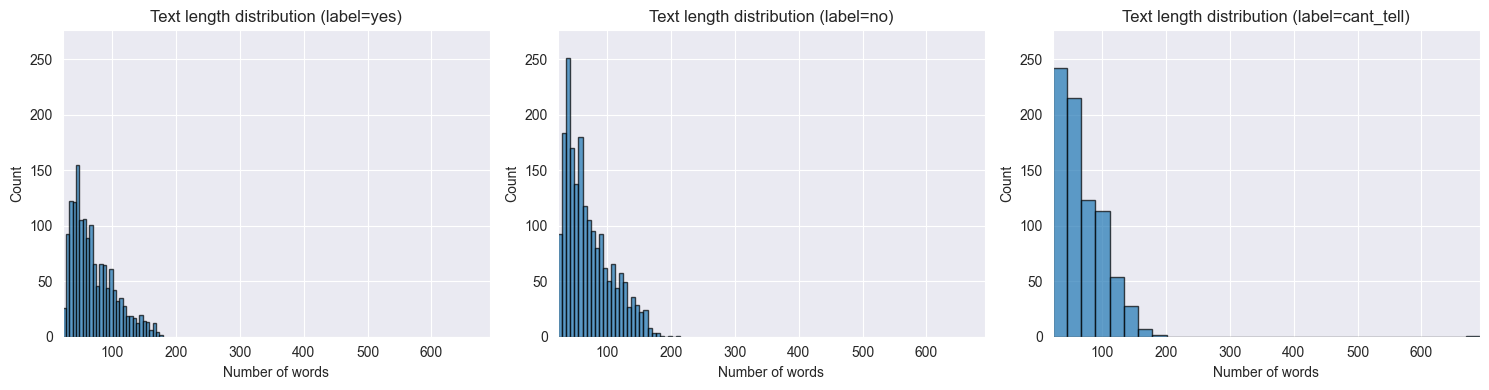


Text length stats by label:
             count       mean        std   min   25%   50%    75%    max
conspiracy                                                              
cant_tell    785.0  68.468790  39.528592  22.0  40.0  60.0  89.00  692.0
no          1990.0  70.644221  35.541577  23.0  42.0  61.0  92.75  214.0
yes         1541.0  69.586632  33.388540  22.0  43.0  61.0  90.00  179.0


In [14]:
# Compute text length (words)
df['n_words'] = df['text'].fillna('').apply(lambda s: len(str(s).split()))

# Histograms of text length by conspiracy label
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Find global min and max for consistent scaling
all_words = df['n_words'].dropna()
x_min = all_words.min()
x_max = all_words.max()
y_max = 0

# First pass: find max count for y-axis
for label in ['yes', 'no', 'cant_tell']:
    subset = df[df['conspiracy'] == label]['n_words'].dropna()
    if len(subset) > 0:
        counts, bins = np.histogram(subset, bins=30)
        y_max = max(y_max, counts.max())

# Second pass: plot with consistent scales
for i, label in enumerate(['yes', 'no', 'cant_tell']):
    subset = df[df['conspiracy'] == label]
    if len(subset) > 0:
        axes[i].hist(subset['n_words'], bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Text length distribution (label={label})')
        axes[i].set_xlabel('Number of words')
        axes[i].set_ylabel('Count')
        # Set consistent x and y limits
        axes[i].set_xlim(x_min, x_max)
        axes[i].set_ylim(0, y_max * 1.1)  # Add 10% padding at top
    else:
        axes[i].set_xlim(x_min, x_max)
        axes[i].set_ylim(0, y_max * 1.1)

plt.tight_layout()
plt.show()

print(f"\nText length stats by label:")
print(df.groupby('conspiracy')['n_words'].describe())


Top 20 marker counts:
     marker  count
0     Actor      0
1    Action      0
2    Victim      0
3  Evidence      0
4    Effect      0


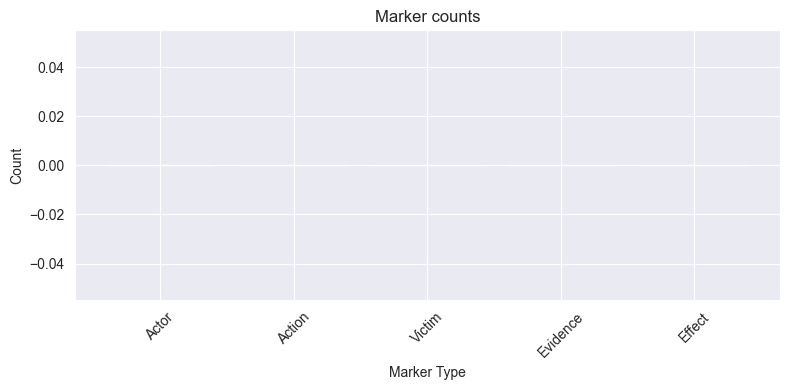

In [11]:
# If markers data is available, show top marker types
import json
marker_types = {'Actor': 0, 'Action': 0, 'Victim': 0, 'Evidence': 0, 'Effect': 0}

for _, row in df.iterrows():
    markers = row.get('markers')
    if isinstance(markers, str):
        try:
            m = json.loads(markers)
            if isinstance(m, dict):
                for mtype in marker_types:
                    if m.get(mtype):
                        marker_types[mtype] += 1
        except:
            pass

marker_df = pd.DataFrame([{'marker': k, 'count': v} for k, v in marker_types.items()])
print("\nTop 20 marker counts:")
print(marker_df.sort_values('count', ascending=False))

# Simple bar plot
plt.figure(figsize=(8, 4))
plt.bar(marker_df['marker'], marker_df['count'])
plt.xlabel('Marker Type')
plt.ylabel('Count')
plt.title('Marker counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

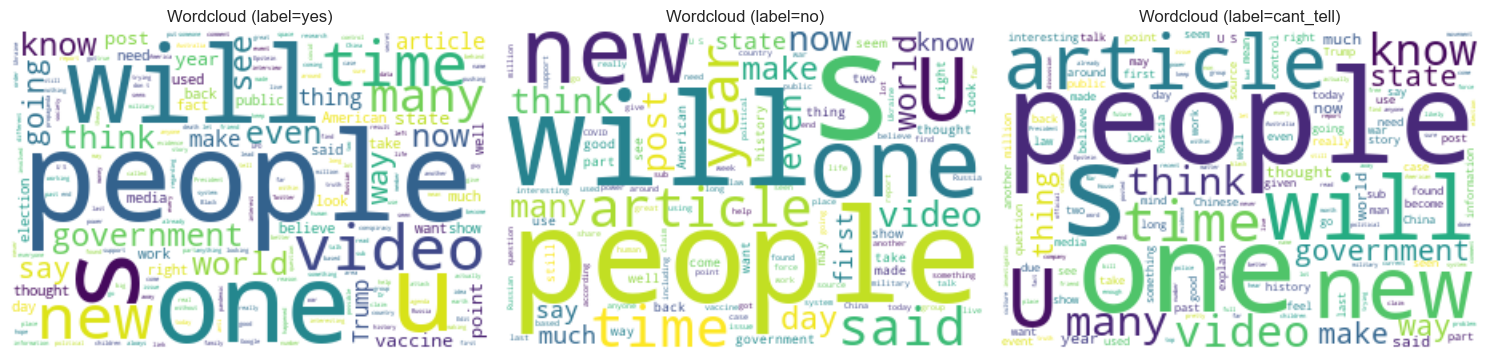

In [12]:
# Wordcloud for each label (top 1000 words per label)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, label in enumerate(['yes', 'no', 'cant_tell']):
    subset = df[df['conspiracy'] == label]
    if len(subset) > 0:
        text = ' '.join(subset['text'].fillna('').astype(str))
        if len(text) > 100:
            wc = WordCloud(width=300, height=200, background_color='white').generate(text)
            axes[i].imshow(wc, interpolation='bilinear')
            axes[i].set_title(f'Wordcloud (label={label})')
            axes[i].axis('off')
plt.tight_layout()
plt.show()

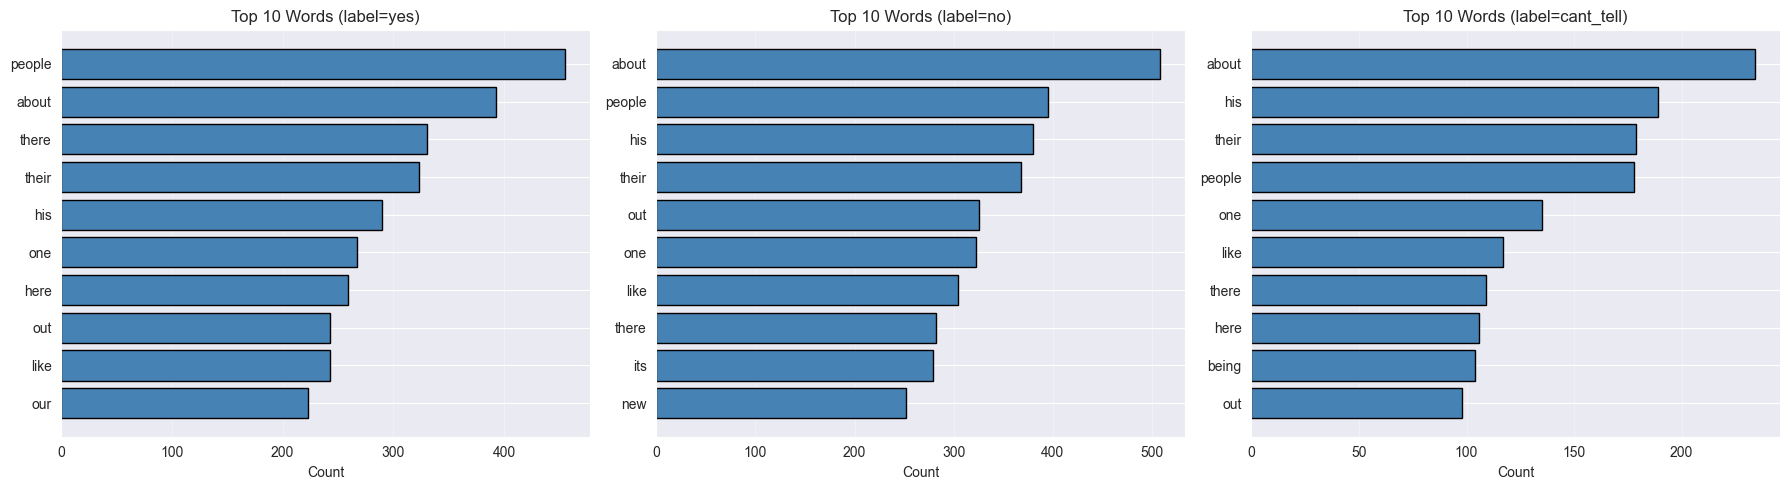

In [13]:
# Optional: Filter common stopwords
from collections import Counter
import re

# Common English stopwords (you can expand this list)
stopwords = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 
             'of', 'with', 'by', 'from', 'as', 'is', 'was', 'are', 'were', 'been',
             'be', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would',
             'could', 'should', 'may', 'might', 'must', 'can', 'this', 'that',
             'these', 'those', 'i', 'you', 'he', 'she', 'it', 'we', 'they',
             'what', 'which', 'who', 'when', 'where', 'why', 'how', 'all', 'each',
             'every', 'both', 'few', 'more', 'most', 'other', 'some', 'such',
             'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too',
             'very', 'just', 'now'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, label in enumerate(['yes', 'no', 'cant_tell']):
    subset = df[df['conspiracy'] == label]
    if len(subset) > 0:
        # Combine all text for this label
        text = ' '.join(subset['text'].fillna('').astype(str))
        # Extract words (lowercase, alphanumeric only) and filter stopwords
        words = [w for w in re.findall(r'\b[a-z]+\b', text.lower()) if w not in stopwords and len(w) > 2]
        # Count word frequencies
        word_counts = Counter(words)
        # Get top 10 words
        top_words = word_counts.most_common(10)
        
        if top_words:
            words_list, counts_list = zip(*top_words)
            axes[i].barh(range(len(words_list)), counts_list, color='steelblue', edgecolor='black')
            axes[i].set_yticks(range(len(words_list)))
            axes[i].set_yticklabels(words_list)
            axes[i].set_xlabel('Count')
            axes[i].set_title(f'Top 10 Words (label={label})')
            axes[i].grid(axis='x', alpha=0.3)
            # Invert y-axis so highest count is at top
            axes[i].invert_yaxis()
        else:
            axes[i].text(0.5, 0.5, 'No words found', ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_title(f'Top 10 Words (label={label})')
    else:
        axes[i].text(0.5, 0.5, 'No data', ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(f'Top 10 Words (label={label})')

plt.tight_layout()
plt.show()